# Python Assignment 17 :Time series

In [71]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df = pd.read_csv("exchange_rate.csv")
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [73]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     7588 non-null   datetime64[ns]
 1   Ex_rate  7588 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 118.7 KB


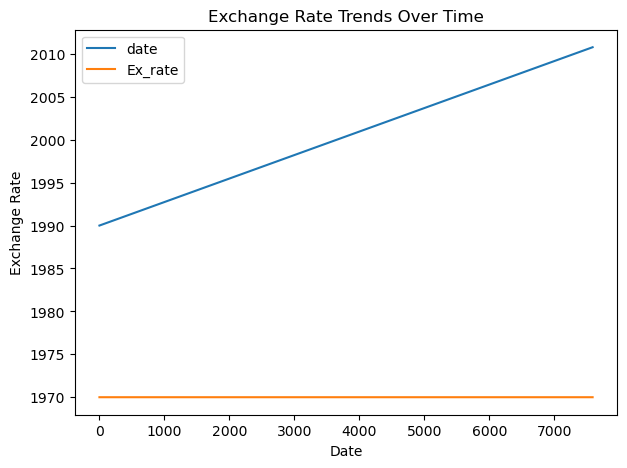

In [75]:
plt.figure(figsize=(7,5))

for column in df.columns:
    plt.plot(df.index, df[column], label=column)

plt.title("Exchange Rate Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()


In [76]:
print(df.isnull().sum())


date       0
Ex_rate    0
dtype: int64


In [77]:
df.fillna(method='ffill', inplace=True)


C:\Users\Thasin\AppData\Local\Temp\ipykernel_18156\4002983762.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


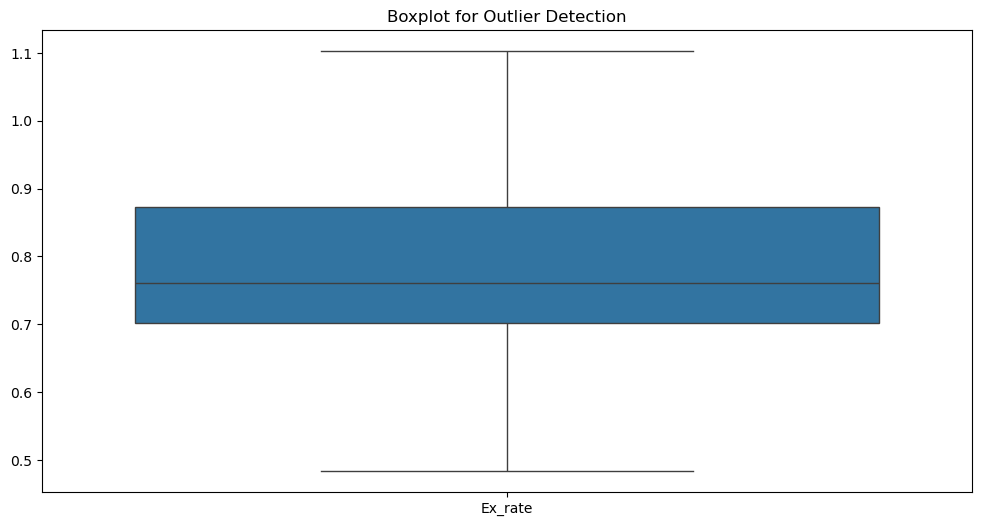

In [78]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("Boxplot for Outlier Detection")
plt.show()


In [79]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Ex_rate'])
print("ADF p-value:", result[1])


ADF p-value: 0.4492327353597985


In [80]:
series_diff = df['Ex_rate'].diff().dropna()

result = adfuller(series_diff)
print("ADF after differencing:", result[1])


ADF after differencing: 0.0


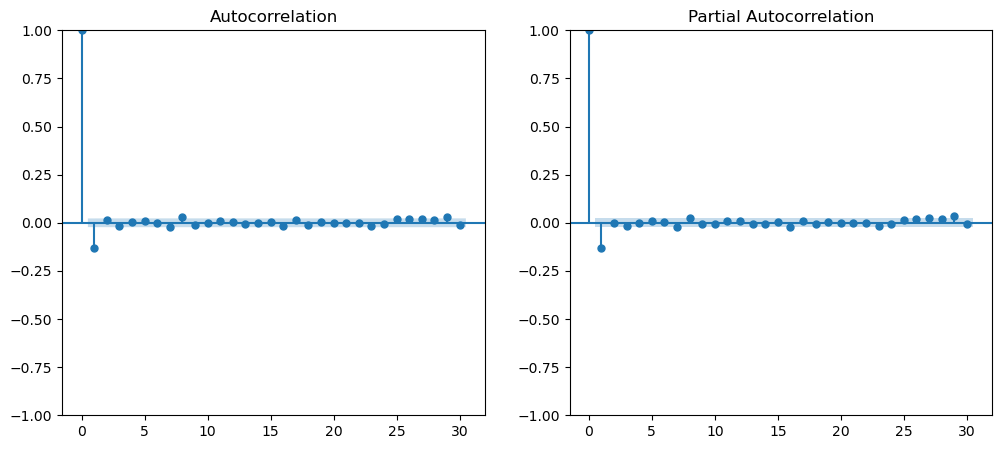

In [81]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(series_diff, lags=30, ax=plt.gca())

plt.subplot(1,2,2)
plot_pacf(series_diff, lags=30, ax=plt.gca())

plt.show()


In [82]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Ex_rate'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Sat, 02 May 2026   AIC                         -56102.322
Time:                        19:34:01   BIC                         -56081.519
Sample:                             0   HQIC                        -56095.182
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

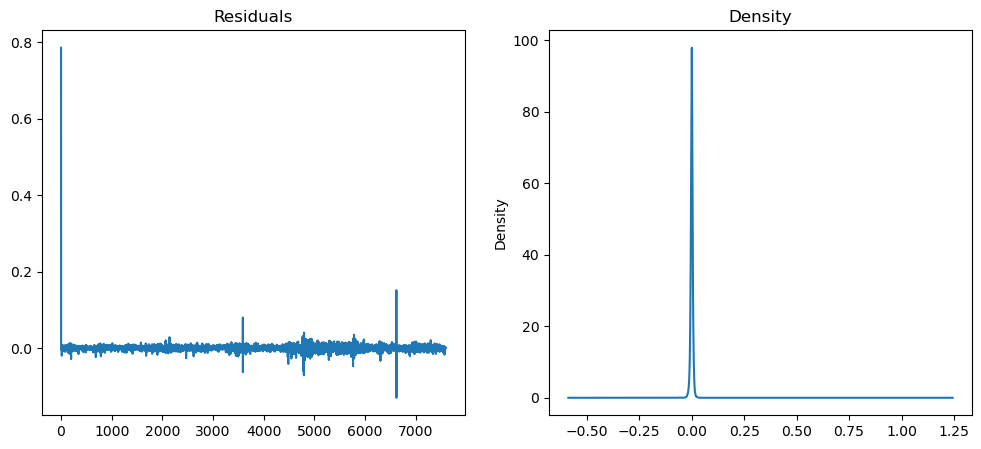

In [83]:
residuals = model_fit.resid

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
residuals.plot(title="Residuals")

plt.subplot(1,2,2)
residuals.plot(kind='kde', title="Density")

plt.show()


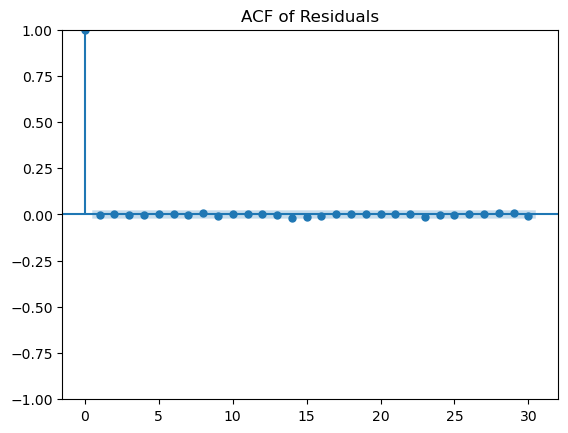

In [84]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals, lags=30)
plt.title("ACF of Residuals")
plt.show()


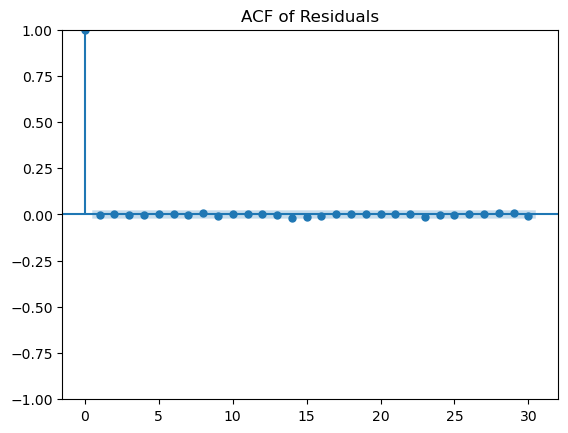

In [85]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals, lags=30)
plt.title("ACF of Residuals")
plt.show()


In [86]:
train = df['Ex_rate'][:int(len(df)*0.8)]
test = df['Ex_rate'][int(len(df)*0.8):]


In [87]:
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()


In [88]:
forecast = model_fit.forecast(steps=len(test))


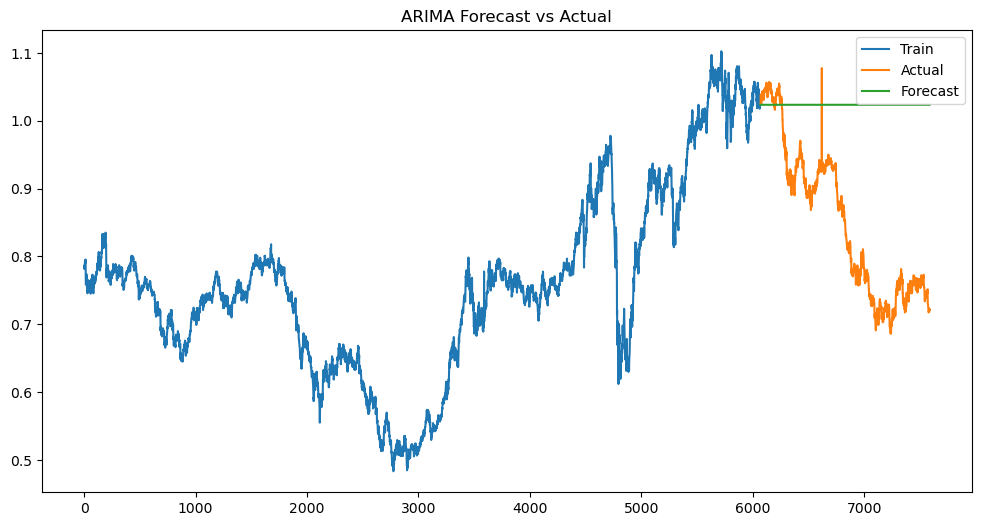

In [89]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.title("ARIMA Forecast vs Actual")
plt.legend()
plt.show()


In [90]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)


RMSE: 0.20543669659668565


In [96]:
mae = mean_absolute_error(test, forecast_arima)


In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)


MAE: 0.17770970449120707
RMSE: 0.20543669659668565
MAPE: 22.79796617381075


In [98]:
# Model 2: Moving Average
forecast_model2 = test.rolling(window=5).mean()
forecast_model2 = forecast_model2.fillna(method='bfill')


C:\Users\Thasin\AppData\Local\Temp\ipykernel_18156\2240549151.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  forecast_model2 = forecast_model2.fillna(method='bfill')


In [99]:
# ARIMA metrics
mae_arima = mean_absolute_error(test, forecast)
rmse_arima = np.sqrt(mean_squared_error(test, forecast))

# Model 2 metrics
mae_m2 = mean_absolute_error(test, forecast_model2)
rmse_m2 = np.sqrt(mean_squared_error(test, forecast_model2))

print("ARIMA -> MAE:", mae_arima, "RMSE:", rmse_arima)
print("Moving Avg -> MAE:", mae_m2, "RMSE:", rmse_m2)


ARIMA -> MAE: 0.17770970449120707 RMSE: 0.20543669659668565
Moving Avg -> MAE: 0.0038073641633728597 RMSE: 0.005932894302802078


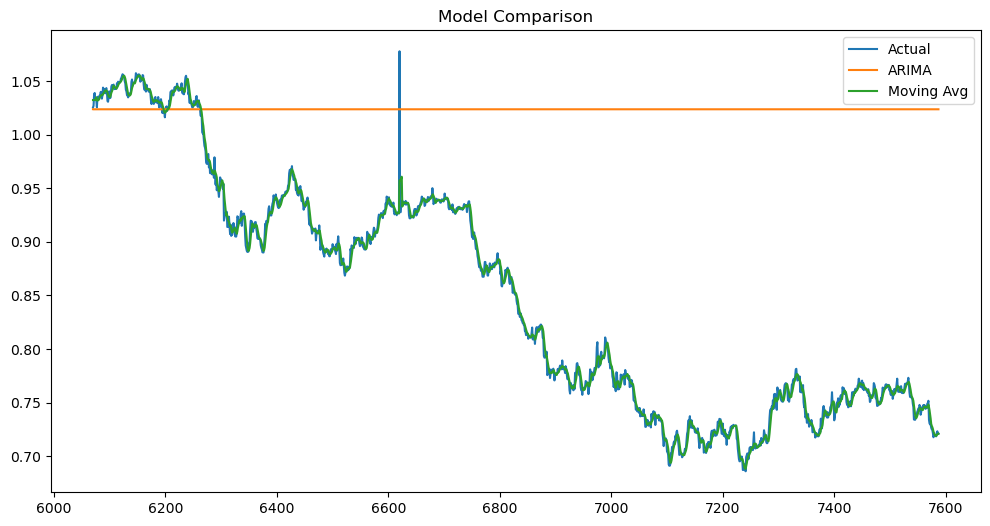

In [100]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='ARIMA')
plt.plot(test.index, forecast_model2, label='Moving Avg')

plt.legend()
plt.title("Model Comparison")
plt.show()
